# Tirando sinais digitais - $x[n]$ ... pra fora do computador - $x(t)$!

Rafael Alencar Delfino - 202504024

Yago Lima Coqueiro - 202504028

Neste Notebook iremos trabalhar em como:
1. Criar um sinal `osc`, com frequência e duração controladas.
2. Sintetizar um sinal ***periódico e aleatório***, com frequência e duração controladas.
3. Plotar sinais em amostras, $x[n]$, tempo, $x(t)$, e frequência, $\mathcal{X}(\omega)$.

In [176]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import sys

In [3]:
try:
    from google.colab import drive

    drive.mount('/content/drive')
    sys.path.append('/content/drive/MyDrive/UFG/01_teaching/')

except ImportError:
    # Local (VSCode/Jupyter): a pasta lib/ fica ao lado deste notebook
    import os
    sys.path.insert(0, os.path.abspath('.'))

In [5]:
from lib.myAudioProcessingLib import *
from lib.mySignalProcessingLib import *

Complete a função `create_sine_signal`, que permite criar um **sinal oscilatório** (*le03, p. 24*):

$$
\Large
x[n] = \, sin(w0n)
$$

controlado pela sua:

- ***frequência*** $(f)$ [Hz] (*le04, p. 11*):

$$
\Large
f = \, fs/P
$$

- e ***duração*** $(d)$ [s] :

$$
\Large
d = N \, T_{s}
$$

In [18]:
def create_sine_signal(f=440.0, dur=1.0, fs=48e3):
    '''
    f  : Signal frequency (Hz)
    dur: Duration (s)
    fs : Sampling frequency
    '''
    N = int(dur*fs)
    n = np.arange(N)
    x = np.sin(2 * np.pi * f / fs * n)
    
    return x, fs


teste sua função, para um sinal de 220 Hz e 1.5 segundos de duração:

In [66]:
f   = 400.0
dur = 1.5

x1, fs1 = create_sine_signal(f, dur)

In [53]:
play(x1, fs1)

Qual é a ***frequencia audível*** do sinal?

In [54]:
# A partir de 300 de frequência consigo ouvir com som baixo

Qual é o período $(P_{1})$, tamanho $(N_{1})$, e frequência de amostragem $(f_{s_{1}})$ do sinal?

In [67]:
P1 = fs1 / f
N1 = len(x1)

print(P1, N1, fs1)

120.0 72000 48000.0


Se mudar a frequencia de amostragem, o que acontece?

In [ ]:
# O período muda, já que é relacionado à frequencia de amostragem.

Agora vamos recriar a mesma função a partir da nossa conhecida primitiva `osc`:

In [63]:
fs2  = 44.1e3

P2 = fs2 / f
N2 = int(dur * fs2)

x2, n2 = SIGNALgenerate(N2, 'osc', P=P2)

In [64]:
play(x2, fs2)

Compare o período $(P_{2})$, tamanho $(N_{2})$, e frequência de amostragem $(f_{s_{2}})$ deste novo sinal com o anterior:

In [68]:
print(P2, N2, fs2)

print(P1, N1, fs1)

147.0 66150 44100.0
120.0 72000 48000.0


In [ ]:
# Resposta

dur = N * Ts -> N / fs
N = d * fs -> np.round(d * fs).astype(int)
f = fs / P
P = np.round(fs / f).astype(int)
x[n]= sin(w0n)
          |-> w0 = 2pi/P

Para verificar o resultado, plote os dois sinais resultantes no "***domínio do tempo***", ou seja, mostrando o **eixo horizontal** em unidade de **segundos**:

$$
\Large
t = n \, T_{s}
$$

***Dica:*** Use `SIGNALplot` para plotar o sinal. \
Se precisar, faça um recorte para melhorar a visualização dos sinais.

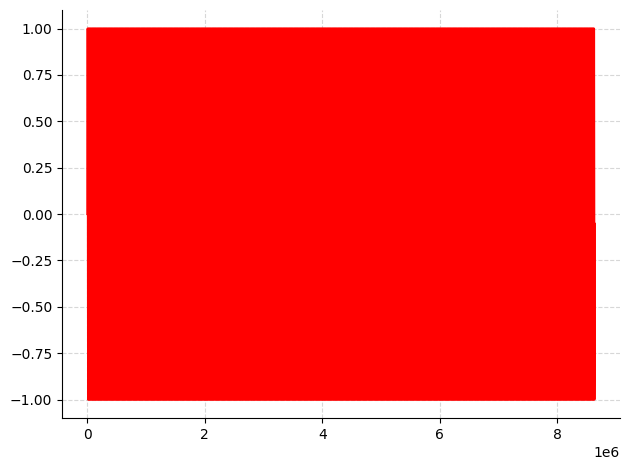

In [78]:
'''
Vetor de tempo
'''
n1 = np.arange(N1)
t1 = n1*P1

'''
Plot
'''
SIGNALplot(x1, t1)

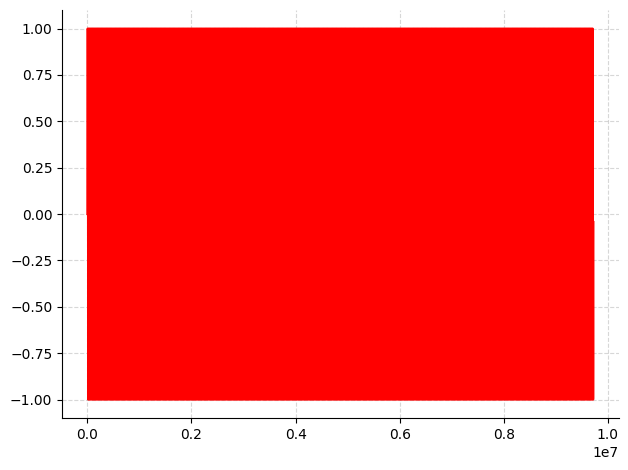

In [79]:
'''
Vetor de tempo
'''
n2 = np.arange(N2)
t2 = n2*P2

'''
Plot
'''
SIGNALplot(x2, t2)

<img src="./figures/sine_01.png" alt="" width="600"/>

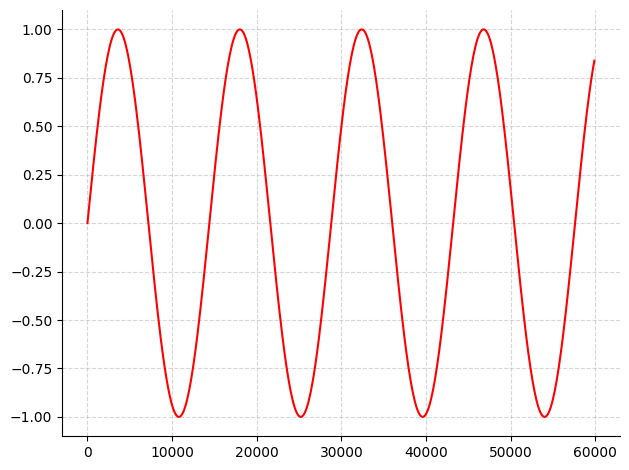

In [80]:
'''
Recorte
'''
r = 500

'''
Plot
'''
SIGNALplot(x1[:r], t1[:r])

<img src="./figures/sine_02.png" alt="" width="600"/>

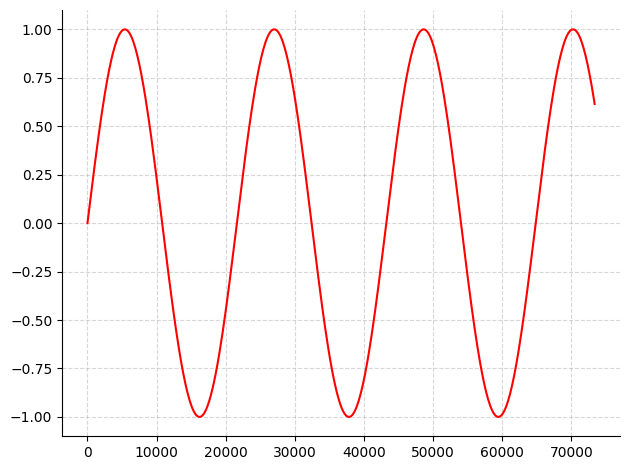

In [81]:
'''
Recorte
'''
r = 500

'''
Plot
'''
SIGNALplot(x2[:r], t2[:r])

Faça um novo recorte para plotar ***apenas*** 2.5 períodos de cada sinal.

***Dica:*** Verifique o resultado mostrando o **eixo horizontal** no "***domínio das amostras***".

<img src="./figures/sine_03.png" alt="" width="600"/>

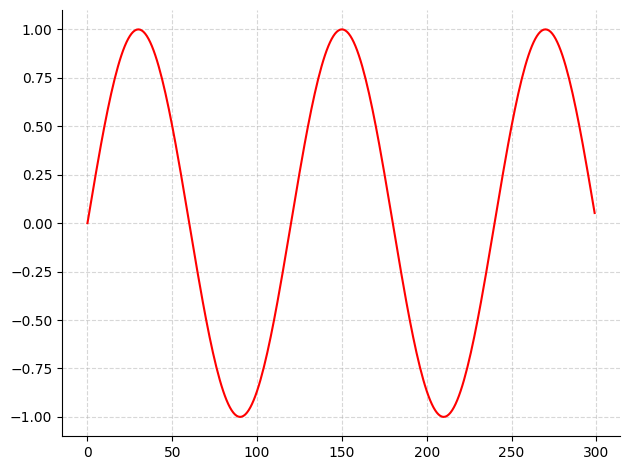

In [89]:
'''
Recorte
'''
r = int(np.round(2.5 * (fs1/f)))

SIGNALplot(x1[:r], n1[:r])

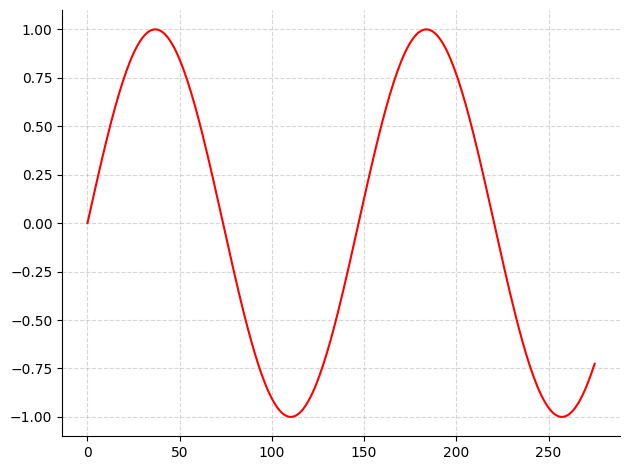

In [90]:
'''
Recorte
'''
r = int(np.round(2.5 * (fs2/f)))

SIGNALplot(x2[:r], n2[:r])

## Desafio

A partir da primitiva `SIGNALgenerate`, aumente a sua **biblioteca de processamento sinais** com a função `SIGNALtone`, que permita criar um ***tom*** controlado por ***frequencia*** e ***duração***.

In [91]:
def SIGNALtone(f=440.0, dur=1.0):
    '''
    Tone with predefined frequency and duration

    f  : Signal frequency (Hz)
    dur: Duration (s)

    x  : Output signal
    fs : Sampling freq. (CD standard by def.)
    '''
    
    fs = 44.1e3 # Sampling freq. (CD standard)

    x, _ = SIGNALgenerate(int(dur * fs), 'osc', P=fs / f)

    return x, fs

Teste a função para um sinal de 330 Hz com 3 segundos de duração.

In [101]:
f = 500.0 # signal freq (Hz)
dur = 3.0 # duration (s)

In [102]:
x, fs = SIGNALtone(f, dur)

In [103]:
play(x, fs)

## Revelando a "*velocidade*" dos sinais

Como comprovar que estamos gerando as frequências corretas?

***Dica:*** Estude a função `np.fft.fft` que permite evidenciar as "*velocidades*" de sinais. \
Use `SIGNALplot` para plotar a **magnitude** da FFT no domínio das amostras.

<img src="./figures/spec_01.png" alt="" width="600"/>

In [104]:
help(np.fft.fft)

Help on function fft in module numpy.fft:

fft(a, n=None, axis=-1, norm=None)
    Compute the one-dimensional discrete Fourier Transform.
    
    This function computes the one-dimensional *n*-point discrete Fourier
    Transform (DFT) with the efficient Fast Fourier Transform (FFT)
    algorithm [CT].
    
    Parameters
    ----------
    a : array_like
        Input array, can be complex.
    n : int, optional
        Length of the transformed axis of the output.
        If `n` is smaller than the length of the input, the input is cropped.
        If it is larger, the input is padded with zeros.  If `n` is not given,
        the length of the input along the axis specified by `axis` is used.
    axis : int, optional
        Axis over which to compute the FFT.  If not given, the last axis is
        used.
    norm : {"backward", "ortho", "forward"}, optional
        .. versionadded:: 1.10.0
    
        Normalization mode (see `numpy.fft`). Default is "backward".
        Indicates w

In [ ]:
# Resposta

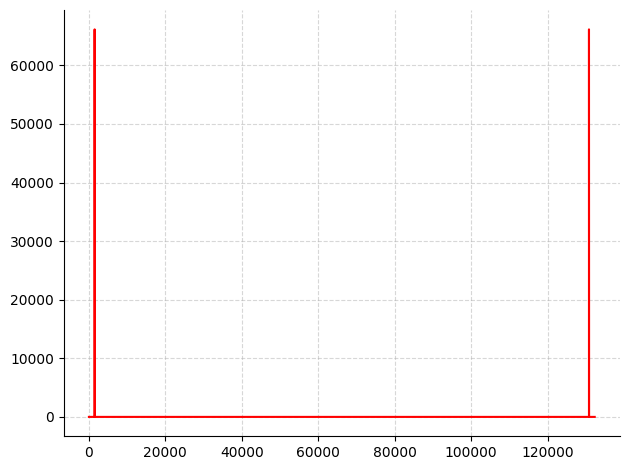

In [105]:
Xmag = np.abs(np.fft.fft(x))
n = np.arange(len(Xmag))

SIGNALplot(Xmag, n)

Aproveitando a ***simetria***, faça um recorte, apropriado, de apenas a metade das amostras.

<img src="./figures/spec_02.png" alt="" width="600"/>

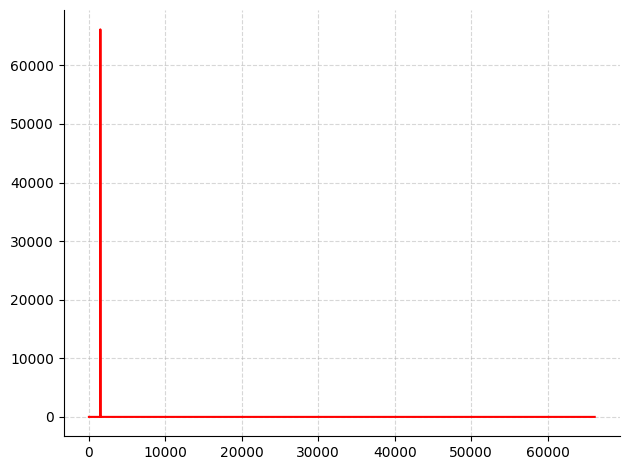

In [107]:
'''
Recorte no dominio das amostras
'''
r = len(Xmag) // 2

SIGNALplot(Xmag[:r], n[:r])

## Plotando as frequências

Agora vamos renomear o eixo horizontal para apresentar o sinal no "***domínio da frequência***":

$$
\Large
f = \frac{n}{N} f_{s}
$$

<img src="./figures/spec_03.png" alt="" width="600"/>

In [115]:
fHz = n / len(Xmag) * fs

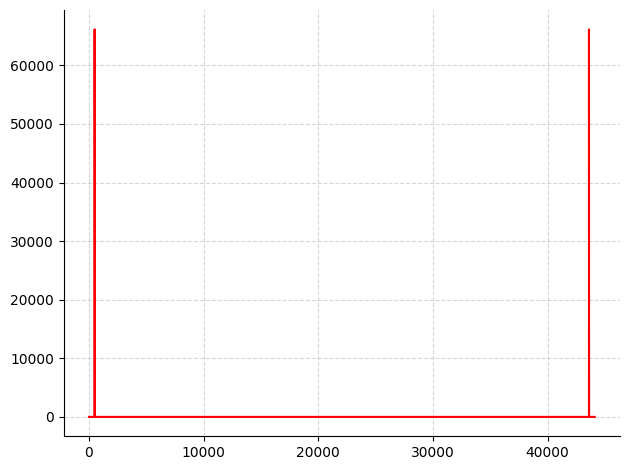

In [116]:
SIGNALplot(Xmag, fHz)

Aproveite o recorte anterior **no domínio das amostras** e aplique-o no sinal.

<img src="./figures/spec_04.png" alt="" width="600"/>

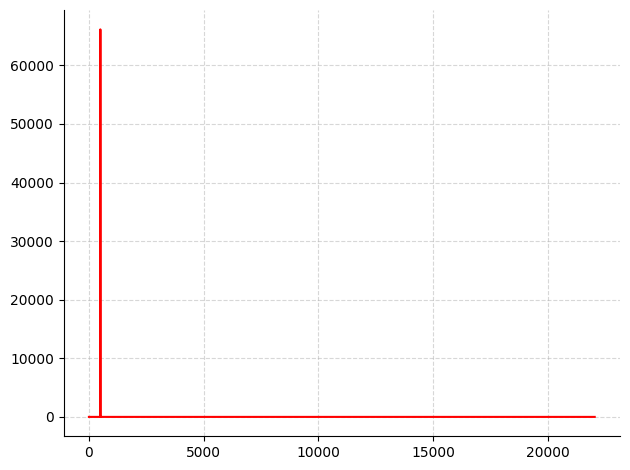

In [117]:
'''
Recorte no dominio das amostras
'''
r = len(Xmag) // 2

SIGNALplot(Xmag[:r], fHz[:r])

Agora, aplique um recorte similar **no domínio das frequências**.

<img src="./figures/spec_05.png" alt="" width="600"/>

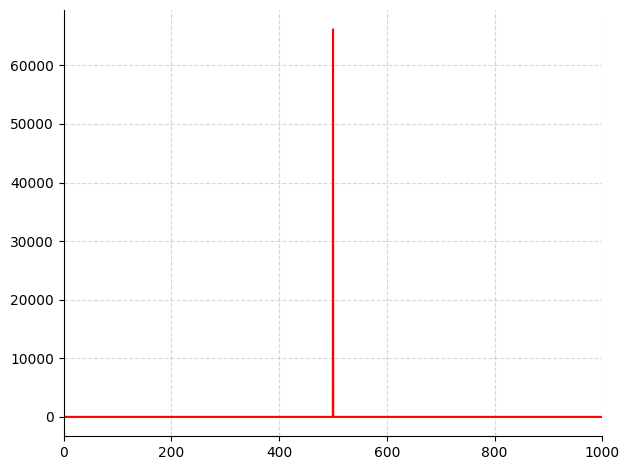

In [118]:
'''
Recorte no dominio das frequencias
'''
SIGNALplot(Xmag, fHz, \
           xlim=[0, 1000])

Plote a ***forma de onda*** e o ***espectro*** para um único sinal com frequencias de 200, 400, 600 e 800 Hz e 1 segundo de duração.

<img src="./figures/sine_04.png" alt="" width="600"/>

<img src="./figures/spec_06.png" alt="" width="600"/>

In [119]:
fs_x = 44.1e3
x = np.zeros(int(1.0 * fs_x))
for fk in [200, 400, 600, 800]:
    xk, _ = SIGNALtone(fk, 1.0)
    x += xk
x = x / 4


nx = np.arange(len(x))
tx = nx / fs_x
Xmag = np.abs(np.fft.fft(x))
fHz_x = nx / len(x) * fs_x

In [120]:
play(x, fs_x)

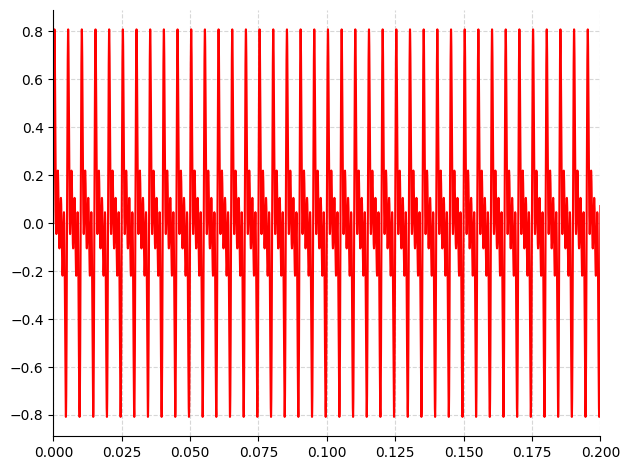

In [121]:
SIGNALplot(x, tx, \
          xlim=[0, 0.2])

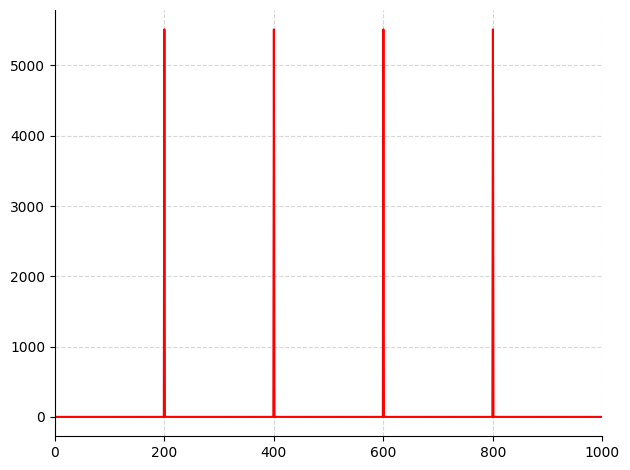

In [122]:
SIGNALplot(Xmag, fHz_x, \
           xlim=[0, 1000])

Oba! Agora sim conseguimos gerar e comprovar as frequencias, ou "*velocidades*", presentes nos sinais!

## Bonus track

A partir da primitiva `SIGNALgenerate`, aumente a sua **biblioteca de processamento sinais** com a função `SIGNALwaveform`, que admita ***tons*** com [***formas de onda*** (*waveforms*)](https://en.wikipedia.org/wiki/Waveform) aleatórias.

***Dica:*** Comece criando um sinal aleatório de tamanho igual a um período. Depois é apenas replicar o sinal até o tamanho final usando `np.concatenate`.

In [167]:
def SIGNALwaveform(f=440.0, dur=1.0):
    '''
    Tone with a random waveform as input

    f  : Signal frequency
    dur: Duration (seconds)

    x  : Output signal
    fs : Sampling freq. (CD standard by def.)
    '''

    fs = 44.1e3
    P = int(round(fs / f))

    waveform, _ = SIGNALgenerate(P, 'random')

    x = np.concatenate([waveform]*int(dur*fs/P))

    return x, fs

Teste a função para um sinal de 110 Hz e 1 segundo de duração.

In [168]:
f = 110.0
dur = 1.0
y, fs = SIGNALwaveform(f, dur)
ny = np.arange(len(y))
Ymag = np.abs(np.fft.fft(y))
fHz_y = np.arange(len(y))*fs/len(y)

In [164]:
play(y, fs)

Verifique a frequencia do sinal gerado. \
O que achou de diferente nele?

<img src="./figures/spec_07.png" alt="" width="600"/>

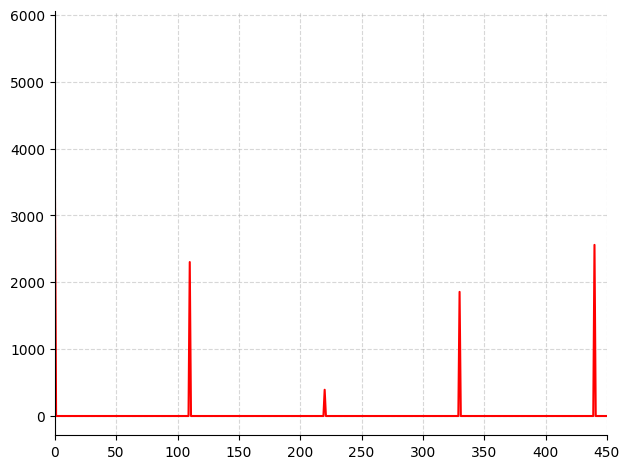

In [175]:
SIGNALplot(Ymag, fHz_y, \
           xlim=[0, 450])

Plote apenas 5 períodos do sinal.

<img src="./figures/signal_01.png" alt="" width="600"/>

In [173]:
P = int(round(fs / 110))
ny = np.arange(len(y))

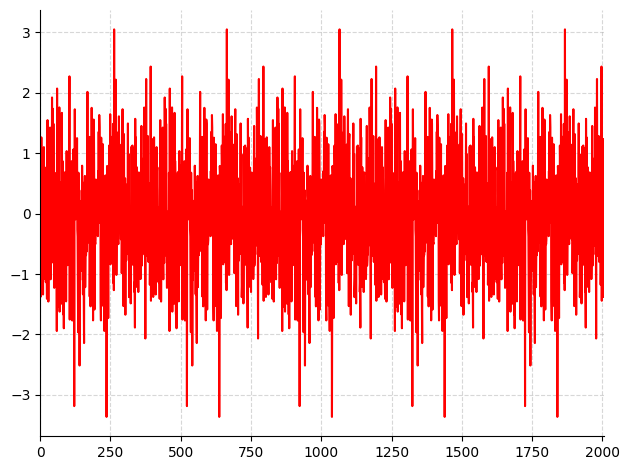

In [174]:
SIGNALplot(y, ny, \
           xlim=[0, 5*P])

Pronto! Agora estamos preparados para analisar sinais no ***domínio da frequência!***